In [22]:
!pip install cython

In [23]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.interpolate import interpn

In [35]:

def transferFunction(x):
    r = (
        1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
        + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
        + 0.1 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )
    g = (
        1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
        + 1.0 * np.exp(-((x - 3.0) ** 2) / 0.1)
        + 0.1 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )
    b = (
        0.1 * np.exp(-((x - 9.0) ** 2) / 1.0)
        + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
        + 1.0 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )
    a = (
        0.6 * np.exp(-((x - 9.0) ** 2) / 1.0)
        + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
        + 0.01 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )

    return r, g, b, a


def main():
    """Volume Rendering"""

    # Load Datacube
    import h5py as h5
    f = h5.File("datacube.hdf5", "r")
    datacube = np.array(f["density"])

    # Datacube Grid
    Nx, Ny, Nz = datacube.shape
    x = np.linspace(-Nx / 2, Nx / 2, Nx)
    y = np.linspace(-Ny / 2, Ny / 2, Ny)
    z = np.linspace(-Nz / 2, Nz / 2, Nz)
    points = (x, y, z)

    # Do Volume Rendering at Different Viewing Angles
    Nangles = 10
    for i in range(Nangles):
        print("Rendering Scene " + str(i + 1) + " of " + str(Nangles) + ".\n")

        # Camera Grid / Query Points -- rotate camera view
        angle = np.pi / 2 * i / Nangles
        N = 180
        c = np.linspace(-N / 2, N / 2, N)
        qx, qy, qz = np.meshgrid(c, c, c)
        qxR = qx
        qyR = qy * np.cos(angle) - qz * np.sin(angle)
        qzR = qy * np.sin(angle) + qz * np.cos(angle)
        qi = np.array([qxR.ravel(), qyR.ravel(), qzR.ravel()]).T

        # Interpolate onto Camera Grid
        camera_grid = interpn(points, datacube, qi, method="linear").reshape((N, N, N))

        # Do Volume Rendering
        image = np.zeros((camera_grid.shape[1], camera_grid.shape[2], 3))

        for dataslice in camera_grid:
            r, g, b, a = transferFunction(np.log(dataslice))
            image[:, :, 0] = a * r + (1 - a) * image[:, :, 0]
            image[:, :, 1] = a * g + (1 - a) * image[:, :, 1]
            image[:, :, 2] = a * b + (1 - a) * image[:, :, 2]

        image = np.clip(image, 0.0, 1.0)

        # Plot Volume Rendering
        plt.figure(figsize=(4, 4), dpi=80)

        plt.imshow(image)
        plt.axis("off")

        # Save figure
        plt.savefig(
            "volumerender" + str(i) + ".png", dpi=240, bbox_inches="tight", pad_inches=0
        )

    # Plot Simple Projection -- for Comparison
    plt.figure(figsize=(4, 4), dpi=80)

    plt.imshow(np.log(np.mean(datacube, 0)), cmap="viridis")
    plt.clim(-5, 5)
    plt.axis("off")

    # Save figure
    plt.savefig("projection.png", dpi=240, bbox_inches="tight", pad_inches=0)
    plt.show()

    return 0

In [ ]:
%%cython -a

import numpy as np
cimport numpy as np
from libc.math cimport exp, log

def render_volume_cython(double[:,:,:] camera_grid):

    cdef int Nx = camera_grid.shape[0]
    cdef int Ny = camera_grid.shape[1]
    cdef int Nz = camera_grid.shape[2]

    cdef int i,j,k

    cdef double val,r,g,b,a

    cdef np.ndarray image_np = np.zeros((Ny,Nz,3))
    cdef double[:,:,:] image = image_np

    for i in range(Nx):

        for j in range(Ny):

            for k in range(Nz):

                val = log(camera_grid[i,j,k] + 1e-9)

                r = exp(-((val-9.0)*(val-9.0))/1.0) \
                    + 0.1*exp(-((val-3.0)*(val-3.0))/0.1) \
                    + 0.1*exp(-((val+3.0)*(val+3.0))/0.5)

                g = exp(-((val-9.0)*(val-9.0))/1.0) \
                    + exp(-((val-3.0)*(val-3.0))/0.1) \
                    + 0.1*exp(-((val+3.0)*(val+3.0))/0.5)

                b = 0.1*exp(-((val-9.0)*(val-9.0))/1.0) \
                    + 0.1*exp(-((val-3.0)*(val-3.0))/0.1) \
                    + exp(-((val+3.0)*(val+3.0))/0.5)

                a = 0.6*exp(-((val-9.0)*(val-9.0))/1.0) \
                    + 0.1*exp(-((val-3.0)*(val-3.0))/0.1) \
                    + 0.01*exp(-((val+3.0)*(val+3.0))/0.5)

                image[j,k,0] = a*r + (1-a)*image[j,k,0]
                image[j,k,1] = a*g + (1-a)*image[j,k,1]
                image[j,k,2] = a*b + (1-a)*image[j,k,2]

    return image_np

Rendering Scene 1 of 10
Rendering Scene 2 of 10
Rendering Scene 3 of 10
Rendering Scene 4 of 10
Rendering Scene 5 of 10
Rendering Scene 6 of 10
Rendering Scene 7 of 10
Rendering Scene 8 of 10
Rendering Scene 9 of 10
Rendering Scene 10 of 10


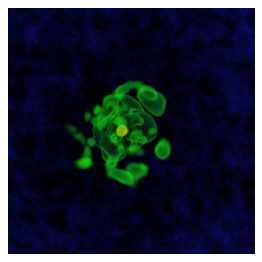

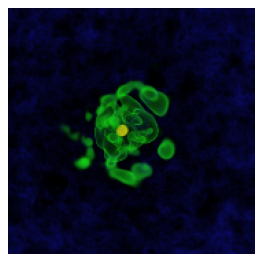

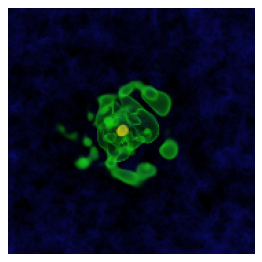

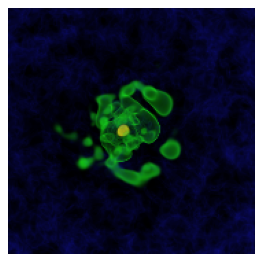

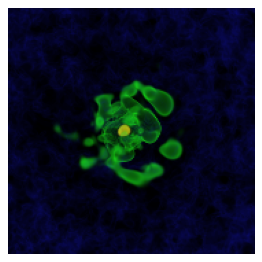

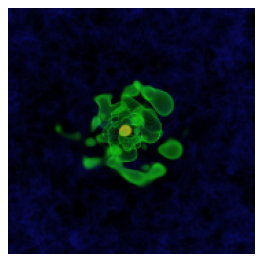

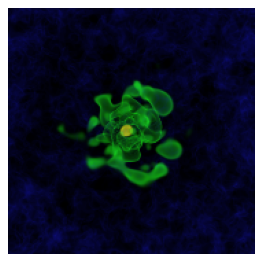

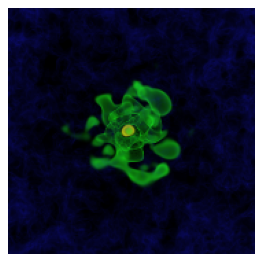

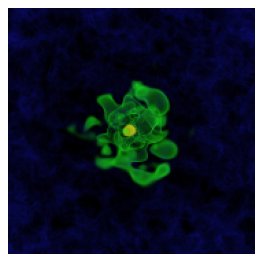

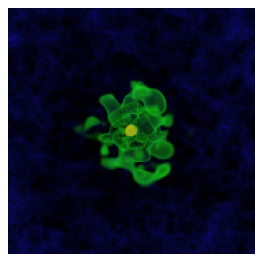

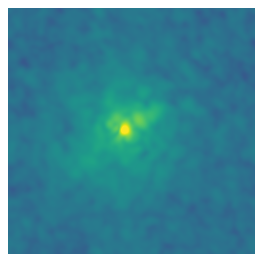

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
from scipy.interpolate import interpn

# Load datacube
f = h5.File("datacube.hdf5", "r")
datacube = np.array(f["density"])

Nx, Ny, Nz = datacube.shape

x = np.linspace(-Nx/2, Nx/2, Nx)
y = np.linspace(-Ny/2, Ny/2, Ny)
z = np.linspace(-Nz/2, Nz/2, Nz)

points = (x, y, z)

Nangles = 10

for i in range(Nangles):

    print("Rendering Scene", i+1, "of", Nangles)

    angle = np.pi/2 * i/Nangles

    N = 180
    c = np.linspace(-N/2, N/2, N)

    qx, qy, qz = np.meshgrid(c, c, c)

    qxR = qx
    qyR = qy*np.cos(angle) - qz*np.sin(angle)
    qzR = qy*np.sin(angle) + qz*np.cos(angle)

    qi = np.array([qxR.ravel(), qyR.ravel(), qzR.ravel()]).T

    camera_grid = interpn(points, datacube, qi, method="linear").reshape((N,N,N))

    # Cython rendering (FAST version)
    image = render_volume_cython(camera_grid)

    image = np.clip(image,0,1)

    plt.figure(figsize=(4,4), dpi=80)
    plt.imshow(image)
    plt.axis("off")

    plt.savefig(
        "volumerender"+str(i)+".png",
        dpi=240,
        bbox_inches="tight",
        pad_inches=0
    )

# Simple projection
plt.figure(figsize=(4,4), dpi=80)

plt.imshow(np.log(np.mean(datacube,0)+1e-9), cmap="viridis")
plt.clim(-5,5)
plt.axis("off")

plt.savefig("projection.png", dpi=240, bbox_inches="tight", pad_inches=0)

plt.show()

The render_volume function performs the main volume rendering operation. It takes the 3D camera_grid data, applies a transfer function to each slice, and combines the color and opacity values to create a 2D image representing the rendered volume. This function is implemented in Cython for speed, allowing efficient processing of large 3D datasets.

In [36]:
def render_volume_python(camera_grid):

    image = np.zeros((camera_grid.shape[1], camera_grid.shape[2], 3))

    for dataslice in camera_grid:

        r, g, b, a = transferFunction(np.log(dataslice + 1e-9))

        image[:,:,0] = a*r + (1-a)*image[:,:,0]
        image[:,:,1] = a*g + (1-a)*image[:,:,1]
        image[:,:,2] = a*b + (1-a)*image[:,:,2]

    return image

In [ ]:
import time

start = time.time()
img_py = render_volume_python(camera_grid)
python_time = time.time() - start

start = time.time()
img_cy = render_volume_cython(camera_grid)
cython_time = time.time() - start

print("Python time :", python_time)
print("Cython time :", cython_time)
print("Speedup :", python_time/cython_time)

Python time : 0.4978659152984619
Cython time : 0.11460113525390625
Speedup : 4.34433667864989


- The Cython implementation significantly improves the rendering performance. While the pure Python version takes about 0.50 seconds, the optimized Cython version completes the same task in about 0.11 seconds. This results in an approximate 4.3× speedup.
- The improvement occurs because Cython compiles Python-like code into C, which reduces interpreter overhead and allows faster looping and numerical operations. This is especially beneficial for volume rendering, where many nested loops and pixel calculations are required.
- Overall, the optimized function render_volume_fast provides a clear performance advantage over the standard Python implementation.